# Peminjaman buku kategori ilmu alam dan mtk

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import altair as alt
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Reshape, GRU, Dense, Dropout, TimeDistributed
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from bayes_opt import BayesianOptimization
from itertools import product

Read Dataset

In [2]:
buku_500 = pd.read_csv('D:\\KuliYeah\\Season 7\\Arc Skripsi\\forecasting\\buku_500.csv')
buku_500['Bulan'] = pd.to_datetime(buku_500['Bulan'], format='%m/%y')

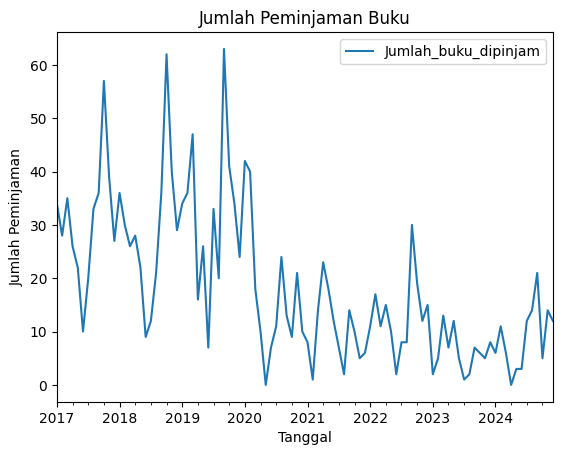

In [3]:
buku_500.plot(x='Bulan', y='Jumlah_buku_dipinjam', kind='line')
plt.title('Jumlah Peminjaman Buku')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Peminjaman')
plt.show()

IQR

        Bulan  Jumlah_buku_dipinjam
9  2017-10-01                    57
21 2018-10-01                    62
32 2019-09-01                    63
Batas bawah: -21.5
Batas atas: 56.5


Text(0, 0.5, 'Jumlah Buku')

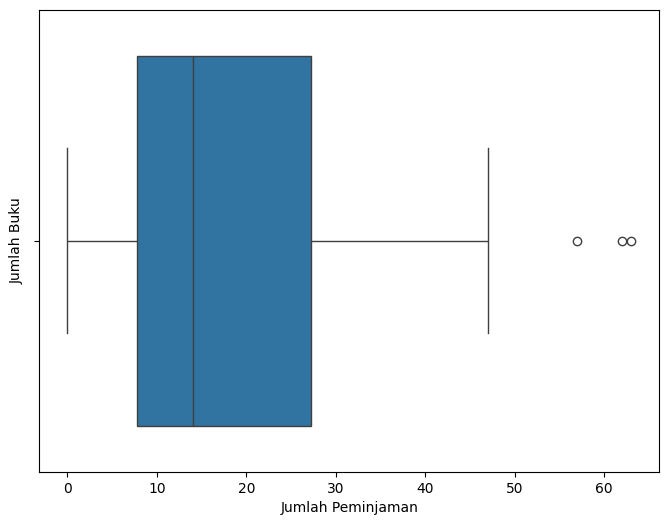

In [4]:
# Menghitung Q1, Q3 dan IQR
Q1 = buku_500['Jumlah_buku_dipinjam'].quantile(0.25)
Q3 = buku_500['Jumlah_buku_dipinjam'].quantile(0.75)
IQR = Q3 - Q1

# Batas bawah dan atas untuk outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
buku_500
outliers_000 = buku_500[(buku_500['Jumlah_buku_dipinjam'] < lower_bound) | (buku_500['Jumlah_buku_dipinjam'] > upper_bound)]

print(outliers_000)
# Menampilkan batas bawah dan atas
print(f"Batas bawah: {lower_bound}")
print(f"Batas atas: {upper_bound}")

plt.figure(figsize=(8, 6))
sns.boxplot(x=buku_500['Jumlah_buku_dipinjam'])
plt.xlabel('Jumlah Peminjaman')
plt.ylabel('Jumlah Buku')

Hyperparameter Tuning

In [5]:
# Rentang hyperparameter
window_sizes = [3, 8, 9]  # Contoh rentang window size
tolerances = [0.5, 1, 2, 2.5, 3]  # Contoh rentang tolerance

# Buat grid kombinasi hyperparameter
grid = list(product(window_sizes, tolerances))

# Simpan hasil tuning
results = []

for window_size, tolerance in grid:
    for tolerance in tolerances:
        buku_500_copy = buku_500.copy()  # Buat salinan data asli agar tidak merusak data asli

        # Rolling median dan rolling std
        buku_500_copy['rolling_median'] = buku_500_copy['Jumlah_buku_dipinjam'].rolling(window=window_size, center=True).median()
        buku_500_copy['rolling_std'] = buku_500_copy['Jumlah_buku_dipinjam'].rolling(window=window_size, center=True).std()

        # Batas atas dan bawah
        upper_bound = buku_500_copy['rolling_median'] + tolerance * buku_500_copy['rolling_std']
        lower_bound = buku_500_copy['rolling_median'] - tolerance * buku_500_copy['rolling_std']

        # Deteksi ou    tlier awal
        detected_outliers = (buku_500_copy['Jumlah_buku_dipinjam'] > upper_bound) | \
                            (buku_500_copy['Jumlah_buku_dipinjam'] < lower_bound)

        # Ganti outlier dengan rolling median
        buku_500_cleaned = buku_500_copy['Jumlah_buku_dipinjam'].copy()
        detected_outliers = (buku_500_copy['Jumlah_buku_dipinjam'] > upper_bound) | \
                            (buku_500_copy['Jumlah_buku_dipinjam'] < lower_bound)
        buku_500_cleaned[detected_outliers] = buku_500_copy['rolling_median'][detected_outliers]


        # Forecasting (contoh dummy prediksi)
        y_actual = buku_500_cleaned[10:]  # Data aktual (tes)
        y_pred = buku_500_cleaned.shift(1)[10:]  # Dummy prediksi

        # Hitung metrik evaluasi
        mape = mean_absolute_percentage_error(y_actual, y_pred)
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

        # Simpan hasil
        results.append({
            'window_size': window_size,
            'tolerance': tolerance,
            'mape': mape,
            'rmse': rmse
        })

# Analisis hasil
results_df = pd.DataFrame(results)
best_result = results_df.sort_values(by='rmse').iloc[0]
print("Kombinasi terbaik berdasarkan MAPE & RMSE: ")
print(best_result)
# Tampilkan semua hasil tuning dari grid search
print("\nSeluruh hasil kombinasi hyperparameter rolling window median:")
for res in results:
    print(f"window_size: {res['window_size']}, Tolerance: {res['tolerance']} -> RMSE: {res['rmse']:.3f}")
# Simpan hasil grid search ke file Excel
results_df.to_excel("rwm buku_500.xlsx", index=False)

C:\Users\asus\AppData\Local\Temp\ipykernel_26564\4144657665.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[27.  27.  29.5 34.5 34.5 24.  24.  25.5 31.5 36.  31.5 31.  29.5 29.5
 29.5 37.  29.  14.5 10.5 10.5 12.  11.  10.  13.  11.   8.5  8.5 10.5
 10.5 10.5 10.5 11.  10.  12.5 12.   9.5  5.   6.5  5.5  6.   6.   6.
  6.   8.5  5.5  8.5 12. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  buku_500_cleaned[detected_outliers] = buku_500_copy['rolling_median'][detected_outliers]
C:\Users\asus\AppData\Local\Temp\ipykernel_26564\4144657665.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[27.  34.5 24.  31.5 31.5 31.  29.5 29.5 10.5 10.5 12.  11.  10.  11.
  8.5 10.5 10.5 11.  12.5 12.   5.   6.5  5.5  6.   6.  12. ]' has dtype incompatible with int64, please explicitly cast

Kombinasi terbaik berdasarkan MAPE & RMSE: 
window_size    8.000000
tolerance      0.500000
mape           0.205427
rmse           3.976311
Name: 25, dtype: float64

Seluruh hasil kombinasi hyperparameter rolling window median:
window_size: 3, Tolerance: 0.5 -> RMSE: 5.516
window_size: 3, Tolerance: 1 -> RMSE: 7.524
window_size: 3, Tolerance: 2 -> RMSE: 11.512
window_size: 3, Tolerance: 2.5 -> RMSE: 11.512
window_size: 3, Tolerance: 3 -> RMSE: 11.512
window_size: 3, Tolerance: 0.5 -> RMSE: 5.516
window_size: 3, Tolerance: 1 -> RMSE: 7.524
window_size: 3, Tolerance: 2 -> RMSE: 11.512
window_size: 3, Tolerance: 2.5 -> RMSE: 11.512
window_size: 3, Tolerance: 3 -> RMSE: 11.512
window_size: 3, Tolerance: 0.5 -> RMSE: 5.516
window_size: 3, Tolerance: 1 -> RMSE: 7.524
window_size: 3, Tolerance: 2 -> RMSE: 11.512
window_size: 3, Tolerance: 2.5 -> RMSE: 11.512
window_size: 3, Tolerance: 3 -> RMSE: 11.512
window_size: 3, Tolerance: 0.5 -> RMSE: 5.516
window_size: 3, Tolerance: 1 -> RMSE: 7.524
w

Outlier handling Rolling Window Median

C:\Users\asus\AppData\Local\Temp\ipykernel_26564\777170726.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[27.  27.  29.5 34.5 34.5 24.  24.  25.5 31.5 36.  31.5 31.  29.5 29.5
 29.5 37.  29.  14.5 10.5 10.5 12.  11.  10.  13.  11.   8.5  8.5 10.5
 10.5 10.5 10.5 11.  10.  12.5 12.   9.5  5.   6.5  5.5  6.   6.   6.
  6.   8.5  5.5  8.5 12. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  buku_500_copy.loc[detected_outliers, 'Jumlah_buku_dipinjam'] = buku_500_copy.loc[detected_outliers, 'rolling_median']


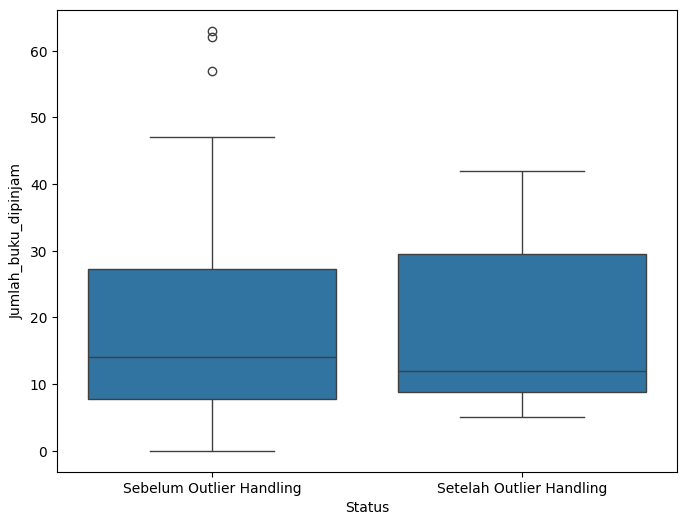

In [6]:
# Ambil kombinasi hyperparameter terbaik
best_window_size = 8
best_tolerance = 0.5

# Salin data asli
buku_500_copy = buku_500.copy()

# Rolling median dan rolling std
buku_500_copy['rolling_median'] = buku_500_copy['Jumlah_buku_dipinjam'].rolling(window=best_window_size, center=True).median()
buku_500_copy['rolling_std'] = buku_500_copy['Jumlah_buku_dipinjam'].rolling(window=best_window_size, center=True).std()

# Batas atas dan bawah
upper_bound = buku_500_copy['rolling_median'] + best_tolerance * buku_500_copy['rolling_std']
lower_bound = buku_500_copy['rolling_median'] - best_tolerance * buku_500_copy['rolling_std']

# Deteksi outlier awal
detected_outliers = (buku_500_copy['Jumlah_buku_dipinjam'] > upper_bound) | \
                    (buku_500_copy['Jumlah_buku_dipinjam'] < lower_bound)

# Ganti outlier dengan rolling median
buku_500_copy.loc[detected_outliers, 'Jumlah_buku_dipinjam'] = buku_500_copy.loc[detected_outliers, 'rolling_median']

# Buat DataFrame untuk visualisasi
buku_500_copy['Status'] = 'Setelah Outlier Handling'
buku_500['Status'] = 'Sebelum Outlier Handling'

df_visual = pd.concat([buku_500[['Jumlah_buku_dipinjam', 'Status']], 
                    buku_500_copy[['Jumlah_buku_dipinjam', 'Status']]])

# Plot Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Status', y='Jumlah_buku_dipinjam', data=df_visual)
plt.show()


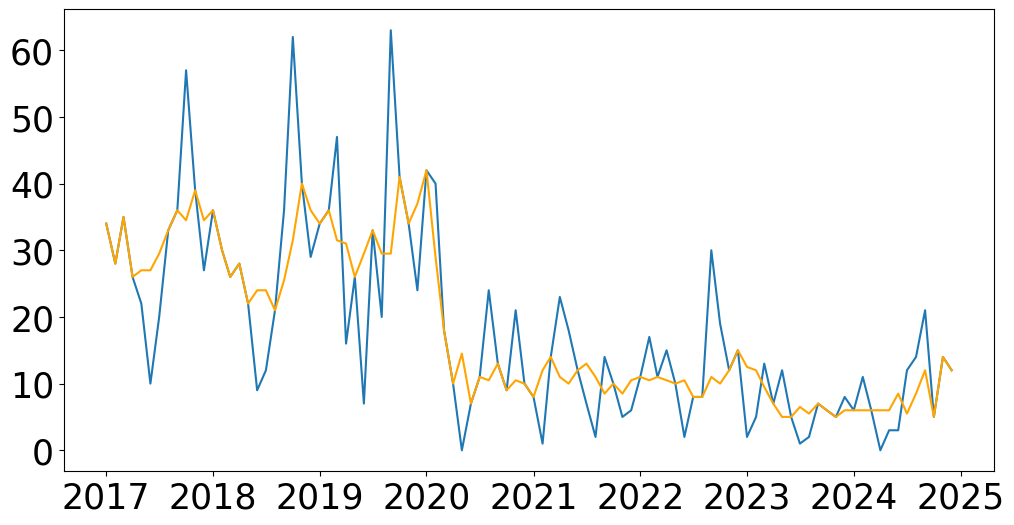

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(buku_500['Bulan'], buku_500['Jumlah_buku_dipinjam'], label='Sebelum Outlier Handling')
plt.plot(buku_500_copy['Bulan'], buku_500_copy['Jumlah_buku_dipinjam'], label='Setelah Outlier Handling', color='orange')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.show()

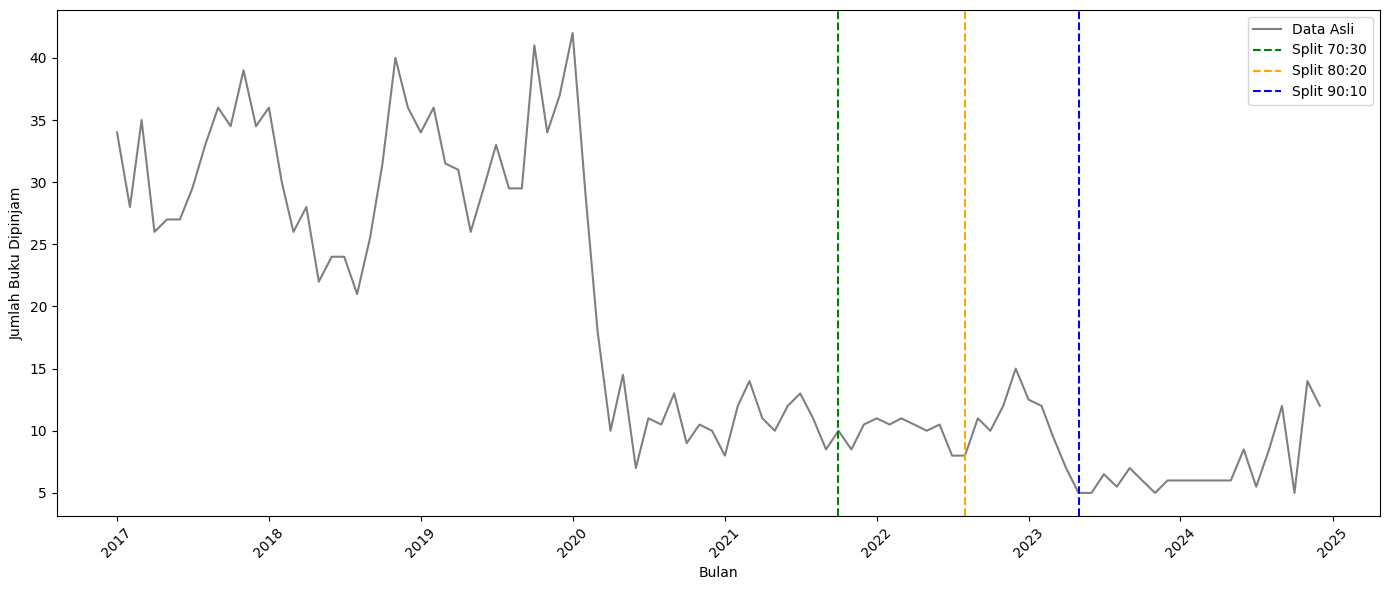

In [8]:
# Ambil data asli sebelum normalisasi untuk referensi
data_original = buku_500_copy[['Jumlah_buku_dipinjam']].values
bulan = buku_500_copy['Bulan'].values  # Ambil label bulan

# Ukuran figure
plt.figure(figsize=(14, 6))

# Daftar rasio split yang ingin ditampilkan
split_ratios = [0.6, 0.7, 0.8]
colors = ['green', 'orange', 'blue']
labels = ['70:30', '80:20', '90:10']

# Plot data original untuk semua bulan sebagai latar
plt.plot(bulan, data_original, label='Data Asli', color='black', alpha=0.5)

# Loop untuk setiap rasio split
for ratio, color, label in zip(split_ratios, colors, labels):
    split_idx = int(len(data_original) * ratio)
    data_train = data_original[:split_idx]
    data_test = data_original[split_idx:]

    bulan_train = bulan[:split_idx]
    bulan_test = bulan[split_idx:]

    # Plot garis split
    plt.axvline(x=bulan[split_idx], color=color, linestyle='--', label=f'Split {label}')

# Label dan tampilan
plt.xticks(rotation=45)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.tight_layout()
plt.show()


# Data split 60:40

Hyperparameter Tunning

In [9]:
# Data awal
X_raw = buku_500_copy[['Jumlah_buku_dipinjam']].values

# Fungsi membuat data dengan timestep
def create_timestep_data(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Grid Search Parameter
param_grid = {
    'timestep': [12, 24],
    'epochs': [50, 100, 170],
    'batch_size': [32, 64, 128],
    'gru_units': [10, 20, 100],
    'cnn_filters': [16, 32, 128],
}

# Inisialisasi variabel terbaik
best_rmse = float('inf')
best_params = None
results = []

# Iterasi seluruh kombinasi parameter
for params in ParameterGrid(param_grid):
    timestep = params['timestep']
    print(f"\nTesting combination: {params}")

    # Buat ulang data dengan timestep baru
    X, y = create_timestep_data(X_raw, timestep)

    # Split train-test (tanpa shuffle)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)

    # Reshape data agar sesuai dengan input model CNN-GRU
    X_train = X_train.reshape((X_train.shape[0], timestep, 1))
    X_test = X_test.reshape((X_test.shape[0], timestep, 1))

    # Normalisasi target
    scaler = MinMaxScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

    # Bangun model CNN-GRU
    model = Sequential()

    # CNN Layer
    model.add(Conv1D(filters=params['cnn_filters'], kernel_size=1, activation='relu', input_shape=(timestep, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())  

    # Reshape sebelum masuk ke GRU
    model.add(Reshape((1, -1)))

    # GRU Layer
    model.add(GRU(params['gru_units'], activation='relu'))  
    model.add(Dropout(0.2))  

    # Output Layer
    model.add(Dense(1))

    # Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train model
    model.fit(X_train, y_train_scaled, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    y_pred_inverse = scaler.inverse_transform(y_pred)
    y_test_inverse = scaler.inverse_transform(y_test_scaled)
    
    mse = mean_squared_error(y_test_inverse, y_pred_inverse)
    rmse = np.sqrt(mse)

    print(f"RMSE: {rmse}")

    # Simpan hasil tuning
    results.append((params, rmse))
    
    # Simpan kombinasi terbaik
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

# Print hasil terbaik
print(f"\nBest RMSE: {best_rmse}")
print(f"Best parameters: {best_params}")

# Display seluruh hasil tuning
for res in results:
    print(f"Params: {res[0]} -> RMSE: {res[1]}")

# Simpan hasil tuning ke Excel
results_df = pd.DataFrame([
    {
        'timestep': r[0]['timestep'],
        'epochs': r[0]['epochs'],
        'batch_size': r[0]['batch_size'],
        'gru_units': r[0]['gru_units'],
        'cnn_filters': r[0]['cnn_filters'],
        'RMSE': r[1]
    }
    for r in results
])

# Simpan ke file Excel
results_df.to_excel("tuning buku_500 60,40.xlsx", index=False)


Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
RMSE: 4.97790542737746

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
RMSE: 5.167170433676311

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12}


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
RMSE: 3.299116036756209

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
RMSE: 3.216254300514279

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
RMSE: 4.212799450469169

Best RMSE: 2.37104885150078
Best parameters: {'batch_size': 64, 'cnn_filters': 32, 'epochs': 170, 'gru_units': 100, 'timestep': 12}
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12} -> RMSE: 4.97790542737746
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24} -> RMSE: 5.167170433676311
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12} -> RMSE: 8.781226657398228
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 24} -> RMSE: 6.005325848668557
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 12} -> RMSE: 3.273082855912532
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 24} -> RMSE: 4.064365237793372
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 100, 'gru_units': 10, 'time

Model CNN-GRU

Epoch 1/100


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.2575
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.2243
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1806
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1498
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.1220
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0997
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0795
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0677
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0570
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0560
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0475
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0538
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0578
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0664
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0699
Epoch 16/100
1/1 ━━━━━━━━━━━━━━━━

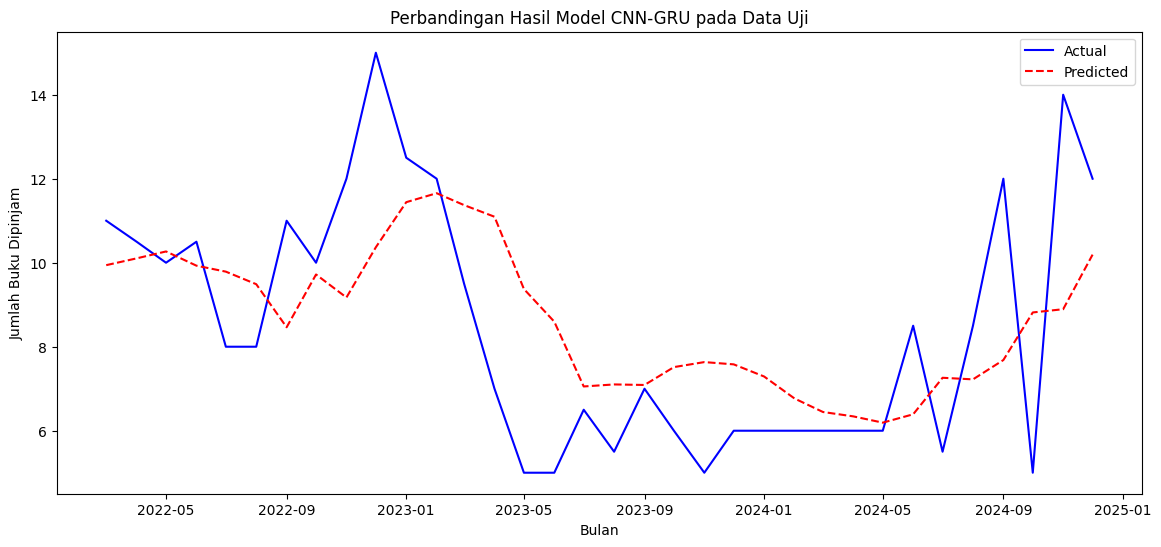

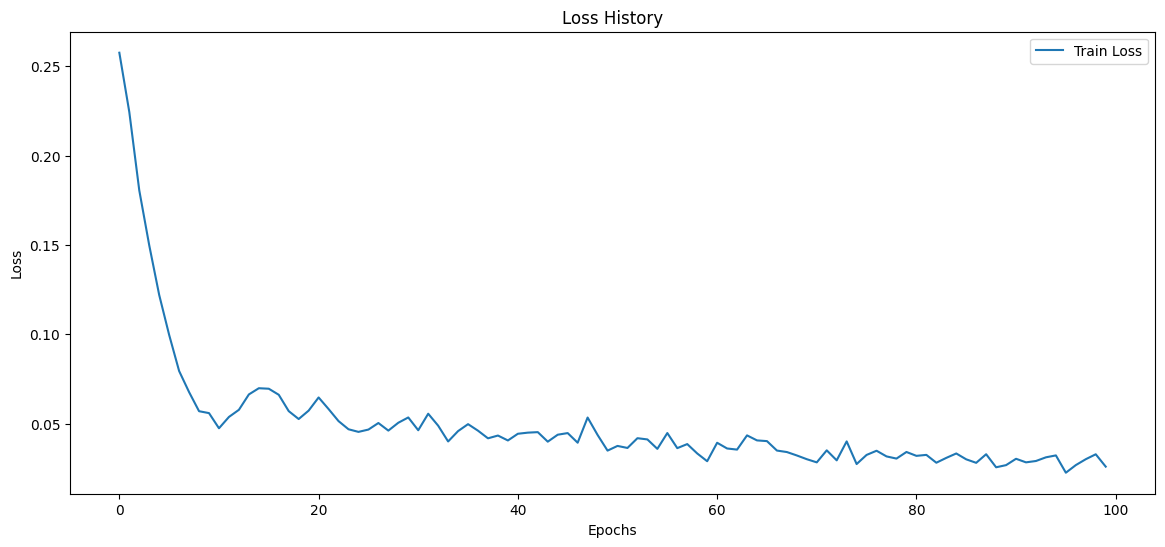

In [10]:
# Parameter window size
timestep = 12  # Menggunakan 6 bulan terakhir sebagai input

# Membentuk data input dengan sliding window
def create_sliding_window(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Memisahkan fitur dan target
X = buku_500_copy[['Jumlah_buku_dipinjam']].values
y = buku_500_copy[['Jumlah_buku_dipinjam']].values

# Normalisasi data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Membuat dataset sliding window
X_window, y_window = create_sliding_window(X_scaled, timestep)

# Split data menjadi train dan test (80% training, 20% testing)
split_idx = int(len(X_window) * 0.6)
X_train, X_test = X_window[:split_idx], X_window[split_idx:]
y_train, y_test = y_window[:split_idx], y_window[split_idx:]

# Reshape input menjadi tiga dimensi (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Membangun Model CNN-GRU
model_cnn_gru = Sequential()

# Lapisan CNN
model_cnn_gru.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(timestep, 1)))
model_cnn_gru.add(MaxPooling1D(pool_size=2))
model_cnn_gru.add(Flatten())

# Ubah kembali ke bentuk tiga dimensi untuk input ke GRU
model_cnn_gru.add(Reshape((1, -1)))

# Lapisan GRU setelah CNN
model_cnn_gru.add(GRU(100, activation='relu'))
model_cnn_gru.add(Dropout(0.2))

# Lapisan output
model_cnn_gru.add(Dense(1))

# Kompilasi model
model_cnn_gru.compile(optimizer='adam', loss='mean_squared_error')

# Latih model
history_model = model_cnn_gru.fit(X_train, y_train, epochs=100, batch_size=64)

# Prediksi pada data uji
y_pred_cnn_gru = model_cnn_gru.predict(X_test)

# Konversi kembali ke skala asli
y_pred_cnn_gru_inverse = scaler.inverse_transform(y_pred_cnn_gru)
y_test_inverse = scaler.inverse_transform(y_test)

# Evaluasi model
mse = mean_squared_error(y_test_inverse, y_pred_cnn_gru_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_cnn_gru_inverse) * 100
mae = mean_absolute_error(y_test_inverse, y_pred_cnn_gru_inverse)

print(f"RMSE: {rmse}")
print(f"MAPE: {mape:.2f}%")

# Plot hasil model (data aktual vs prediksi)
plt.figure(figsize=(14, 6))
plt.plot(buku_500_copy['Bulan'][-len(y_test_inverse):], y_test_inverse, label='Actual', color='blue')
plt.plot(buku_500_copy['Bulan'][-len(y_pred_cnn_gru_inverse):], y_pred_cnn_gru_inverse, label='Predicted', linestyle='--', color='red')
plt.title('Perbandingan Hasil Model CNN-GRU pada Data Uji')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()

# plot loss
plt.figure(figsize=(14, 6))
plt.plot(history_model.history['loss'], label='Train Loss')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Prediksi dalam skala normalisasi:
[[0.1450259 ]
 [0.13308668]
 [0.11684721]
 [0.09413742]
 [0.08757772]
 [0.07910271]
 [0.07605988]
 [0.07943142]
 [0.08003416]
 [0.08205371]
 [0.08269569]
 [0.07976411]]
Prediksi dalam skala asli:
[[10]
 [ 9]
 [ 9]
 [ 8]
 [ 8]
 [ 7]
 [ 7]
 [ 7]
 [ 7]
 [ 8]
 [ 8]
 [ 7]]
Hasil prediksi dalam DataFrame:
        Bulan  Prediksi
0  2024-12-31        10
1  2025-01-31         9
2  2025-02-28         9
3  2025-03-31         8
4  2025-04-30         8
5  2025-05-31         7
6  2025-06-30         7
7  2025-07-31    

C:\Users\asus\AppData\Local\Temp\ipykernel_21192\2129690552.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=buku_500_copy['Bulan'].values[-1], periods=12, freq='M')


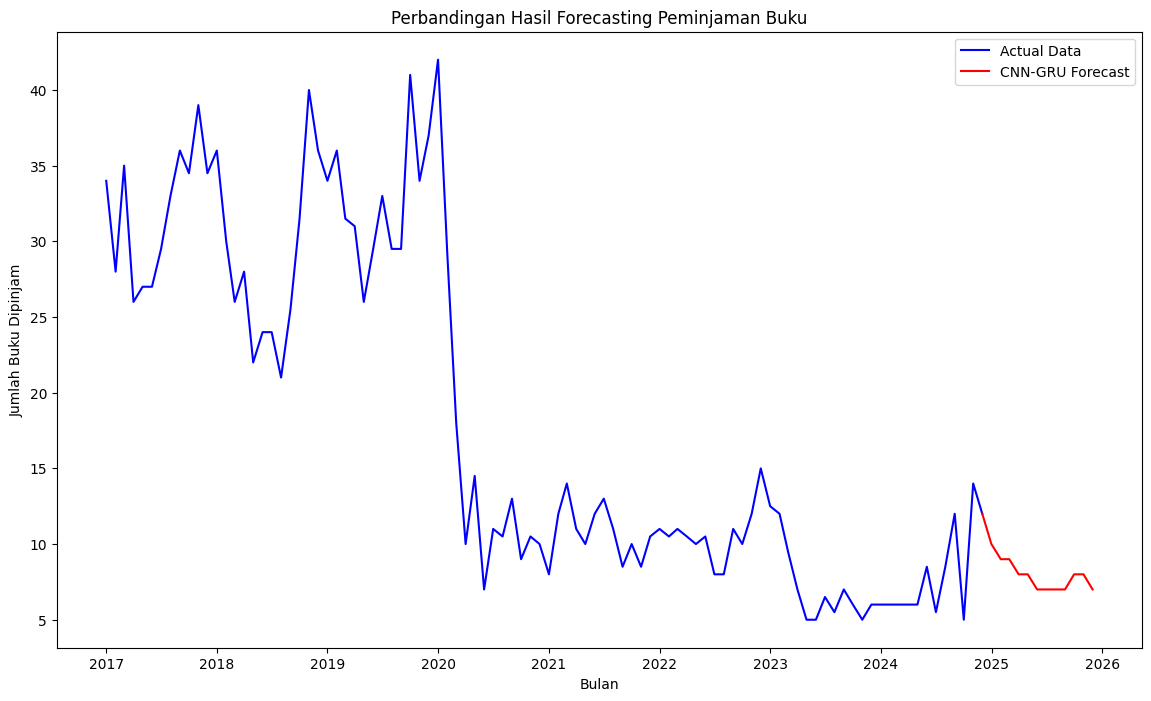

In [10]:
# Prediksi 12 bulan ke depan menggunakan sliding window
def predict_future(model, last_input, months=12):
    future_predictions = []
    current_input = last_input.copy()

    for _ in range(months):
        prediction = model.predict(current_input.reshape((1, timestep, 1)))
        future_predictions.append(prediction[0, 0])
        
        # Geser input window dengan menambahkan prediksi terbaru
        current_input = np.roll(current_input, -1)
        current_input[-1] = prediction[0, 0]

    return np.array(future_predictions).reshape(-1, 1)

# Gunakan data terakhir sebagai input awal
last_input = X_scaled[-timestep:]
future_preds_scaled = predict_future(model_cnn_gru, last_input, months=12)

# Cek nilai sebelum inverse transform
print("Prediksi dalam skala normalisasi:")
print(future_preds_scaled)

# Konversi kembali ke skala asli
future_preds = scaler.inverse_transform(future_preds_scaled)

# Konversi kembali ke skala asli dan ubah ke bilangan bulat
future_preds = scaler.inverse_transform(future_preds_scaled).astype(int)

# Cek nilai setelah inverse transform
print("Prediksi dalam skala asli:")
print(future_preds)

# Buat label bulan untuk prediksi
future_dates = pd.date_range(start=buku_500_copy['Bulan'].values[-1], periods=12, freq='M')

# Simpan hasil prediksi dalam DataFrame untuk analisis lebih lanjut
predictions_df = pd.DataFrame({'Bulan': future_dates, 'Prediksi': future_preds.flatten()})
print("Hasil prediksi dalam DataFrame:")
print(predictions_df)

# Gabungkan data aktual dan prediksi
combined_dates = np.concatenate([buku_500_copy['Bulan'].values, future_dates])
combined_values = np.concatenate([buku_500_copy['Jumlah_buku_dipinjam'].values, future_preds.flatten()])

# Visualisasi hasil prediksi dengan satu garis tetapi warna berbeda
plt.figure(figsize=(14, 8))

# Plot data aktual dengan warna biru
plt.plot(combined_dates[:len(buku_500_copy)], combined_values[:len(buku_500_copy)], color='blue', label='Actual Data')

# Plot data prediksi dengan warna merah (melanjutkan garis sebelumnya)
plt.plot(combined_dates[len(buku_500_copy)-1:], combined_values[len(buku_500_copy)-1:], color='red', label='CNN-GRU Forecast')

plt.title('Perbandingan Hasil Forecasting Peminjaman Buku')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()


# Data split 70:30

Hyperparameter Tunning

In [11]:
# Data awal
X_raw = buku_500_copy[['Jumlah_buku_dipinjam']].values

# Fungsi membuat data dengan timestep
def create_timestep_data(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Grid Search Parameter
param_grid = {
    'timestep': [12, 24],
    'epochs': [50, 100, 170],
    'batch_size': [32, 64, 128],
    'gru_units': [10, 20, 100],
    'cnn_filters': [16, 32, 128],
}

# Inisialisasi variabel terbaik
best_rmse = float('inf')
best_params = None
results = []

# Iterasi seluruh kombinasi parameter
for params in ParameterGrid(param_grid):
    timestep = params['timestep']
    print(f"\nTesting combination: {params}")

    # Buat ulang data dengan timestep baru
    X, y = create_timestep_data(X_raw, timestep)

    # Split train-test (tanpa shuffle)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

    # Reshape data agar sesuai dengan input model CNN-GRU
    X_train = X_train.reshape((X_train.shape[0], timestep, 1))
    X_test = X_test.reshape((X_test.shape[0], timestep, 1))

    # Normalisasi target
    scaler = MinMaxScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

    # Bangun model CNN-GRU
    model = Sequential()

    # CNN Layer
    model.add(Conv1D(filters=params['cnn_filters'], kernel_size=1, activation='relu', input_shape=(timestep, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())  

    # Reshape sebelum masuk ke GRU
    model.add(Reshape((1, -1)))

    # GRU Layer
    model.add(GRU(params['gru_units'], activation='relu'))  
    model.add(Dropout(0.2))  

    # Output Layer
    model.add(Dense(1))

    # Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train model
    model.fit(X_train, y_train_scaled, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    y_pred_inverse = scaler.inverse_transform(y_pred)
    y_test_inverse = scaler.inverse_transform(y_test_scaled)
    
    mse = mean_squared_error(y_test_inverse, y_pred_inverse)
    rmse = np.sqrt(mse)

    print(f"RMSE: {rmse}")

    # Simpan hasil tuning
    results.append((params, rmse))
    
    # Simpan kombinasi terbaik
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

# Print hasil terbaik
print(f"\nBest RMSE: {best_rmse}")
print(f"Best parameters: {best_params}")

# Display seluruh hasil tuning
for res in results:
    print(f"Params: {res[0]} -> RMSE: {res[1]}")

# Simpan hasil tuning ke Excel
results_df = pd.DataFrame([
    {
        'timestep': r[0]['timestep'],
        'epochs': r[0]['epochs'],
        'batch_size': r[0]['batch_size'],
        'gru_units': r[0]['gru_units'],
        'cnn_filters': r[0]['cnn_filters'],
        'RMSE': r[1]
    }
    for r in results
])

# Simpan ke file Excel
results_df.to_excel("tuning buku_500 70,30.xlsx", index=False)


Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
RMSE: 3.0143269917283115

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
RMSE: 2.8542601727535764

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12}


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
RMSE: 4.114325767579906

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
RMSE: 2.6090569242627826

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
RMSE: 4.496007313707993

Best RMSE: 2.3340940144645352
Best parameters: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 100, 'gru_units': 20, 'timestep': 12}
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12} -> RMSE: 3.0143269917283115
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24} -> RMSE: 2.8542601727535764
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12} -> RMSE: 2.926751514259316
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 24} -> RMSE: 6.441574295173159
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 12} -> RMSE: 3.3740250872702466
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 24} -> RMSE: 3.3877046865882967
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 100, 'gru_units': 1

Model CNN-GRU

Epoch 1/100


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.1925
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.1701
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1485
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.1296
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1038
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0900
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0730
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0530
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0482
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0586
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0413
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0501
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0582
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0675
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0666
Epoch 16/100
1/1 ━━━━━━━━━━━━━━━━

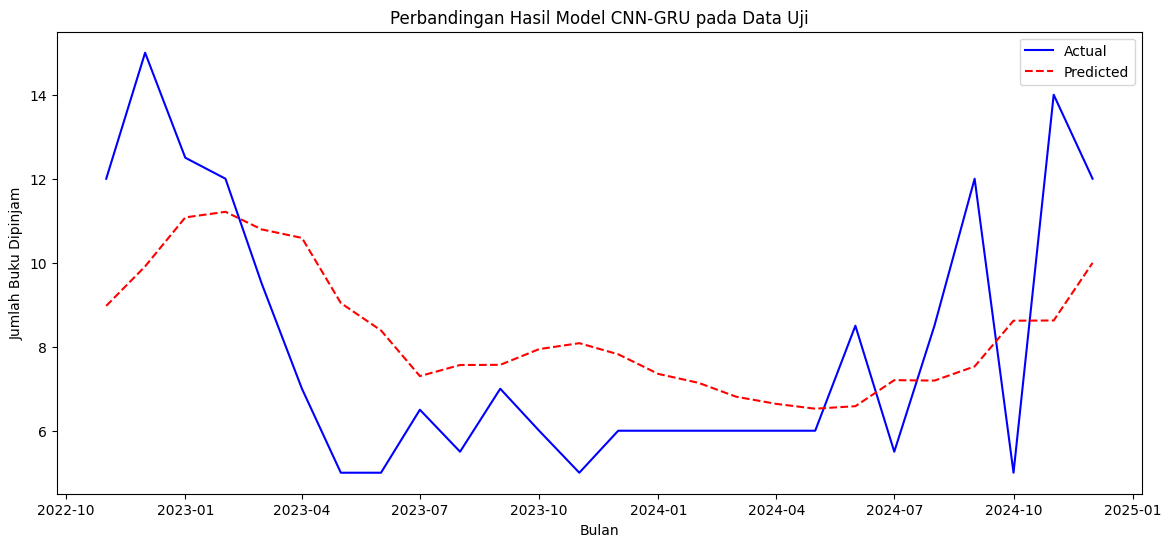

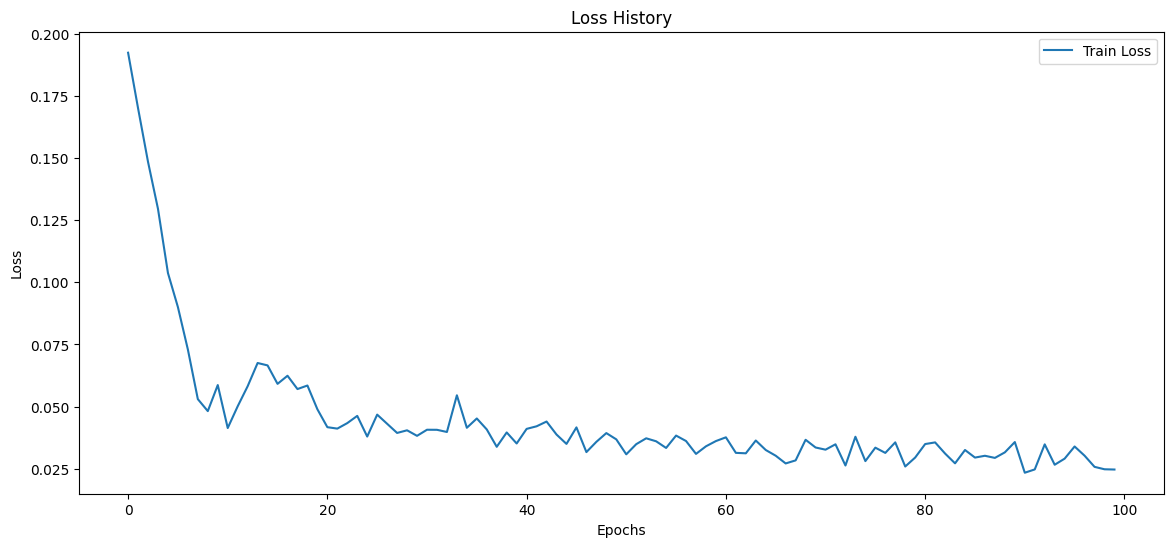

In [22]:
# Parameter window size
timestep = 12  # Menggunakan 6 bulan terakhir sebagai input

# Membentuk data input dengan sliding window
def create_sliding_window(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Memisahkan fitur dan target
X = buku_500_copy[['Jumlah_buku_dipinjam']].values
y = buku_500_copy[['Jumlah_buku_dipinjam']].values

# Normalisasi data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Membuat dataset sliding window
X_window, y_window = create_sliding_window(X_scaled, timestep)

# Split data menjadi train dan test (80% training, 20% testing)
split_idx = int(len(X_window) * 0.7)
X_train, X_test = X_window[:split_idx], X_window[split_idx:]
y_train, y_test = y_window[:split_idx], y_window[split_idx:]

# Reshape input menjadi tiga dimensi (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Membangun Model CNN-GRU
model_cnn_gru = Sequential()

# Lapisan CNN
model_cnn_gru.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(timestep, 1)))
model_cnn_gru.add(MaxPooling1D(pool_size=2))
model_cnn_gru.add(Flatten())

# Ubah kembali ke bentuk tiga dimensi untuk input ke GRU
model_cnn_gru.add(Reshape((1, -1)))

# Lapisan GRU setelah CNN
model_cnn_gru.add(GRU(20, activation='relu'))
model_cnn_gru.add(Dropout(0.2))

# Lapisan output
model_cnn_gru.add(Dense(1))

# Kompilasi model
model_cnn_gru.compile(optimizer='adam', loss='mean_squared_error')

# Latih model
history_model = model_cnn_gru.fit(X_train, y_train, epochs=100, batch_size=128)

# Prediksi pada data uji
y_pred_cnn_gru = model_cnn_gru.predict(X_test)

# Konversi kembali ke skala asli
y_pred_cnn_gru_inverse = scaler.inverse_transform(y_pred_cnn_gru)
y_test_inverse = scaler.inverse_transform(y_test)

# Evaluasi model
mse = mean_squared_error(y_test_inverse, y_pred_cnn_gru_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_cnn_gru_inverse) * 100
mae = mean_absolute_error(y_test_inverse, y_pred_cnn_gru_inverse)

print(f"RMSE: {rmse}")
print(f"MAPE: {mape:.2f}%")

# Plot hasil model (data aktual vs prediksi)
plt.figure(figsize=(14, 6))
plt.plot(buku_500_copy['Bulan'][-len(y_test_inverse):], y_test_inverse, label='Actual', color='blue')
plt.plot(buku_500_copy['Bulan'][-len(y_pred_cnn_gru_inverse):], y_pred_cnn_gru_inverse, label='Predicted', linestyle='--', color='red')
plt.title('Perbandingan Hasil Model CNN-GRU pada Data Uji')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()

# plot loss
plt.figure(figsize=(14, 6))
plt.plot(history_model.history['loss'], label='Train Loss')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediksi dalam skala normalisasi:
[[0.13768819]
 [0.12713124]
 [0.11179107]
 [0.09815904]
 [0.08928783]
 [0.0889844 ]
 [0.0843645 ]
 [0.09513466]
 [0.09599283]
 [0.09844726]
 [0.09684774]
 [0.09054787]]
Prediksi dalam skala asli:
[[10]
 [ 9]
 [ 9]
 [ 8]
 [ 8]
 [ 8]
 [ 8]
 [ 8]
 [ 8]
 [ 8]
 [ 8]
 [ 8]]
Hasil prediksi dalam DataFrame:
        Bulan  Prediksi
0  2024-12-31        10
1  2025-01-31         9
2  2025-02-28         9
3  2025-03-31         8
4  2025-04-30         8
5  2025-05-31         8
6  2025-06-30         8
7  2025-07-31   

C:\Users\asus\AppData\Local\Temp\ipykernel_21192\2129690552.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=buku_500_copy['Bulan'].values[-1], periods=12, freq='M')


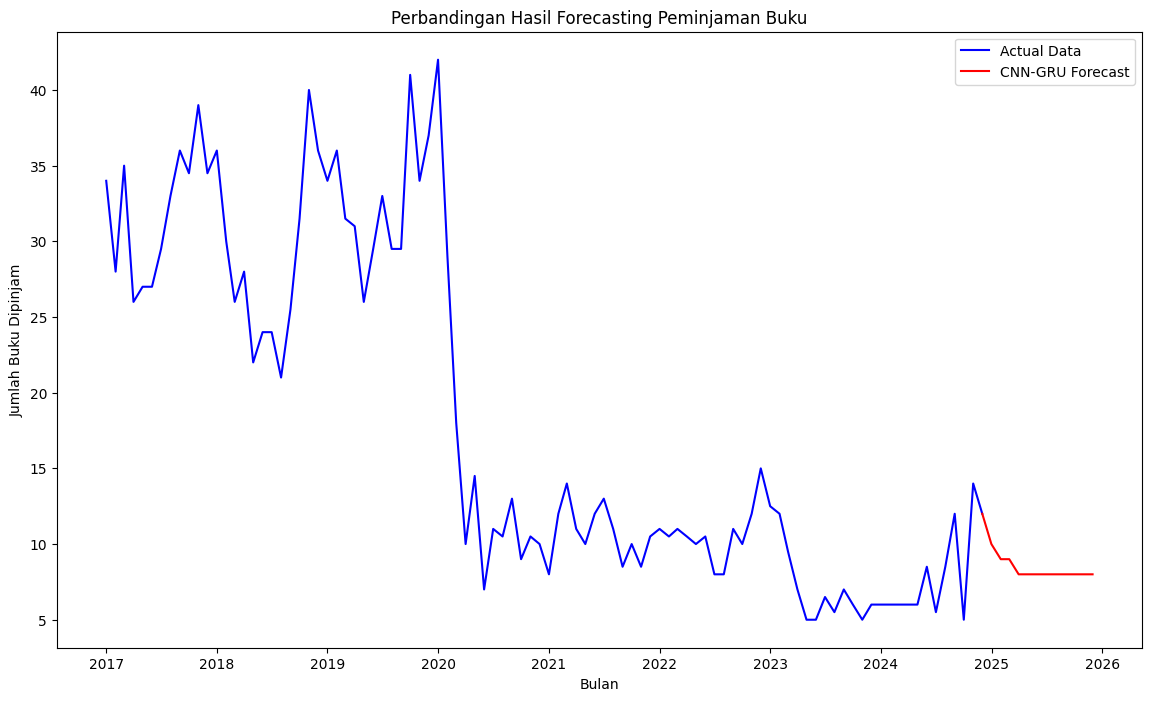

In [23]:
# Prediksi 12 bulan ke depan menggunakan sliding window
def predict_future(model, last_input, months=12):
    future_predictions = []
    current_input = last_input.copy()

    for _ in range(months):
        prediction = model.predict(current_input.reshape((1, timestep, 1)))
        future_predictions.append(prediction[0, 0])
        
        # Geser input window dengan menambahkan prediksi terbaru
        current_input = np.roll(current_input, -1)
        current_input[-1] = prediction[0, 0]

    return np.array(future_predictions).reshape(-1, 1)

# Gunakan data terakhir sebagai input awal
last_input = X_scaled[-timestep:]
future_preds_scaled = predict_future(model_cnn_gru, last_input, months=12)

# Cek nilai sebelum inverse transform
print("Prediksi dalam skala normalisasi:")
print(future_preds_scaled)

# Konversi kembali ke skala asli
future_preds = scaler.inverse_transform(future_preds_scaled)

# Konversi kembali ke skala asli dan ubah ke bilangan bulat
future_preds = scaler.inverse_transform(future_preds_scaled).astype(int)

# Cek nilai setelah inverse transform
print("Prediksi dalam skala asli:")
print(future_preds)

# Buat label bulan untuk prediksi
future_dates = pd.date_range(start=buku_500_copy['Bulan'].values[-1], periods=12, freq='M')

# Simpan hasil prediksi dalam DataFrame untuk analisis lebih lanjut
predictions_df = pd.DataFrame({'Bulan': future_dates, 'Prediksi': future_preds.flatten()})
print("Hasil prediksi dalam DataFrame:")
print(predictions_df)

# Gabungkan data aktual dan prediksi
combined_dates = np.concatenate([buku_500_copy['Bulan'].values, future_dates])
combined_values = np.concatenate([buku_500_copy['Jumlah_buku_dipinjam'].values, future_preds.flatten()])

# Visualisasi hasil prediksi dengan satu garis tetapi warna berbeda
plt.figure(figsize=(14, 8))

# Plot data aktual dengan warna biru
plt.plot(combined_dates[:len(buku_500_copy)], combined_values[:len(buku_500_copy)], color='blue', label='Actual Data')

# Plot data prediksi dengan warna merah (melanjutkan garis sebelumnya)
plt.plot(combined_dates[len(buku_500_copy)-1:], combined_values[len(buku_500_copy)-1:], color='red', label='CNN-GRU Forecast')

plt.title('Perbandingan Hasil Forecasting Peminjaman Buku')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()


# Data split 80:20

Hyperparameter Tunning

In [24]:
# Data awal
X_raw = buku_500_copy[['Jumlah_buku_dipinjam']].values

# Fungsi membuat data dengan timestep
def create_timestep_data(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Grid Search Parameter
param_grid = {
    'timestep': [12, 24],
    'epochs': [50, 100, 170],
    'batch_size': [32, 64, 128],
    'gru_units': [10, 20, 100],
    'cnn_filters': [16, 32, 128],
}

# Inisialisasi variabel terbaik
best_rmse = float('inf')
best_params = None
results = []

# Iterasi seluruh kombinasi parameter
for params in ParameterGrid(param_grid):
    timestep = params['timestep']
    print(f"\nTesting combination: {params}")

    # Buat ulang data dengan timestep baru
    X, y = create_timestep_data(X_raw, timestep)

    # Split train-test (tanpa shuffle)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Reshape data agar sesuai dengan input model CNN-GRU
    X_train = X_train.reshape((X_train.shape[0], timestep, 1))
    X_test = X_test.reshape((X_test.shape[0], timestep, 1))

    # Normalisasi target
    scaler = MinMaxScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

    # Bangun model CNN-GRU
    model = Sequential()

    # CNN Layer
    model.add(Conv1D(filters=params['cnn_filters'], kernel_size=1, activation='relu', input_shape=(timestep, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())  

    # Reshape sebelum masuk ke GRU
    model.add(Reshape((1, -1)))

    # GRU Layer
    model.add(GRU(params['gru_units'], activation='relu'))  
    model.add(Dropout(0.2))  

    # Output Layer
    model.add(Dense(1))

    # Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train model
    model.fit(X_train, y_train_scaled, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
    
    # Evaluate model
    y_pred = model.predict(X_test)
    y_pred_inverse = scaler.inverse_transform(y_pred)
    y_test_inverse = scaler.inverse_transform(y_test_scaled)
    
    mse = mean_squared_error(y_test_inverse, y_pred_inverse)
    rmse = np.sqrt(mse)

    print(f"RMSE: {rmse}")

    # Simpan hasil tuning
    results.append((params, rmse))
    
    # Simpan kombinasi terbaik
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

# Print hasil terbaik
print(f"\nBest RMSE: {best_rmse}")
print(f"Best parameters: {best_params}")

# Display seluruh hasil tuning
for res in results:
    print(f"Params: {res[0]} -> RMSE: {res[1]}")

# Simpan hasil tuning ke Excel
results_df = pd.DataFrame([
    {
        'timestep': r[0]['timestep'],
        'epochs': r[0]['epochs'],
        'batch_size': r[0]['batch_size'],
        'gru_units': r[0]['gru_units'],
        'cnn_filters': r[0]['cnn_filters'],
        'RMSE': r[1]
    }
    for r in results
])

# Simpan ke file Excel
results_df.to_excel("tuning buku_500 80,20.xlsx", index=False)


Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
RMSE: 4.653808381066315

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
RMSE: 3.2251624994351733

Testing combination: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12}


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
RMSE: 2.877383278813174

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 12}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
RMSE: 2.4565295282794266

Testing combination: {'batch_size': 128, 'cnn_filters': 128, 'epochs': 170, 'gru_units': 100, 'timestep': 24}


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
RMSE: 2.5002443337972666

Best RMSE: 1.738822581467875
Best parameters: {'batch_size': 64, 'cnn_filters': 16, 'epochs': 100, 'gru_units': 10, 'timestep': 24}
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 12} -> RMSE: 4.653808381066315
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 10, 'timestep': 24} -> RMSE: 3.2251624994351733
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 12} -> RMSE: 2.800754841358316
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 20, 'timestep': 24} -> RMSE: 3.133638772953002
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 12} -> RMSE: 2.338048944559598
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 50, 'gru_units': 100, 'timestep': 24} -> RMSE: 2.853532251126335
Params: {'batch_size': 32, 'cnn_filters': 16, 'epochs': 100, 'gru_units': 10, 't

Model CNN-GRU

c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.1522
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 0.0991
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0703
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0525
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0494
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0501
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.0478
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0622
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0510
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0534
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0483
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0423
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0339
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0351
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0357
Epoch 16/100

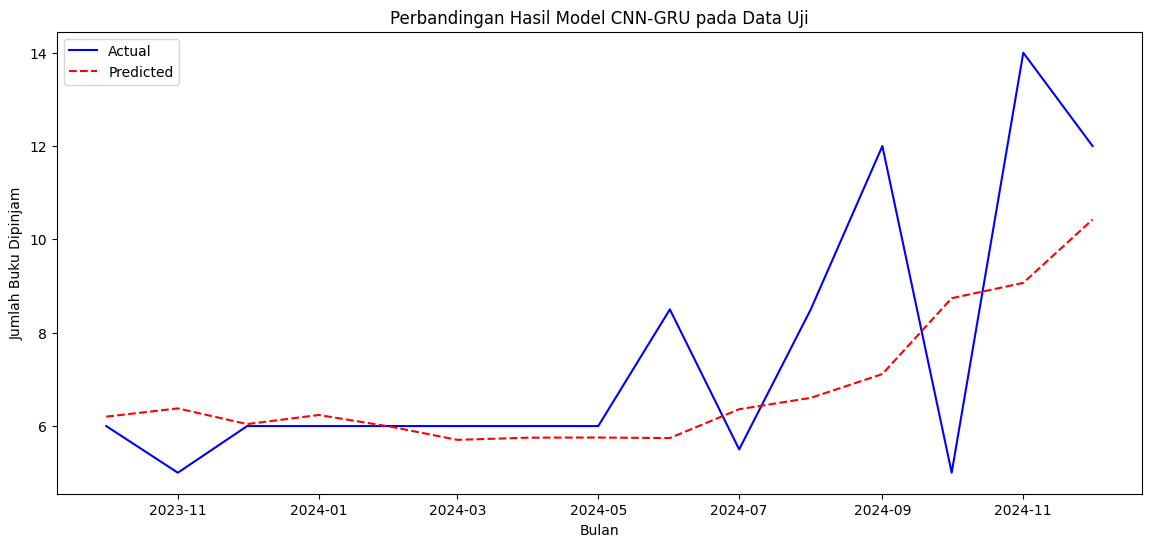

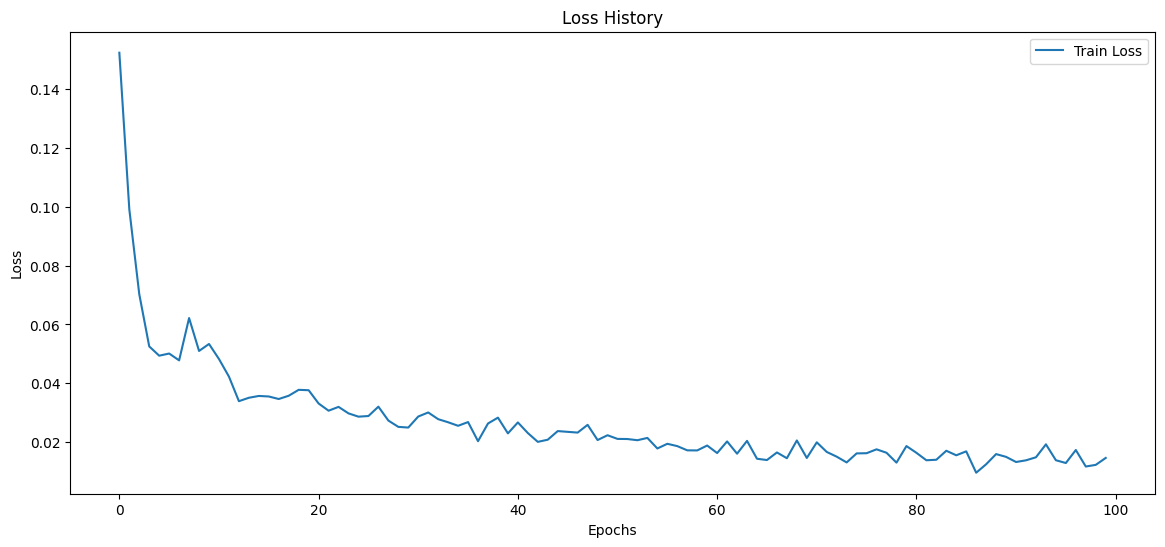

In [9]:
# Parameter window size
timestep = 24  # Menggunakan 6 bulan terakhir sebagai input

# Membentuk data input dengan sliding window
def create_sliding_window(data, timestep):
    X, y = [], []
    for i in range(len(data) - timestep):
        X.append(data[i:i+timestep])
        y.append(data[i+timestep])
    return np.array(X), np.array(y)

# Memisahkan fitur dan target
X = buku_500_copy[['Jumlah_buku_dipinjam']].values
y = buku_500_copy[['Jumlah_buku_dipinjam']].values

# Normalisasi data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Membuat dataset sliding window
X_window, y_window = create_sliding_window(X_scaled, timestep)

# Split data menjadi train dan test (80% training, 20% testing)
split_idx = int(len(X_window) * 0.8)
X_train, X_test = X_window[:split_idx], X_window[split_idx:]
y_train, y_test = y_window[:split_idx], y_window[split_idx:]

# Reshape input menjadi tiga dimensi (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Membangun Model CNN-GRU
model_cnn_gru = Sequential()

# Lapisan CNN
model_cnn_gru.add(Conv1D(filters=16, kernel_size=1, activation='relu', input_shape=(timestep, 1)))
model_cnn_gru.add(MaxPooling1D(pool_size=2))
model_cnn_gru.add(Flatten())

# Ubah kembali ke bentuk tiga dimensi untuk input ke GRU
model_cnn_gru.add(Reshape((1, -1)))

# Lapisan GRU setelah CNN
model_cnn_gru.add(GRU(100, activation='relu'))
model_cnn_gru.add(Dropout(0.2))

# Lapisan output
model_cnn_gru.add(Dense(1))

# Kompilasi model
model_cnn_gru.compile(optimizer='adam', loss='mean_squared_error')

# Latih model
history_model = model_cnn_gru.fit(X_train, y_train, epochs=100, batch_size=64)

# Prediksi pada data uji
y_pred_cnn_gru = model_cnn_gru.predict(X_test)

# Konversi kembali ke skala asli
y_pred_cnn_gru_inverse = scaler.inverse_transform(y_pred_cnn_gru)
y_test_inverse = scaler.inverse_transform(y_test)

# Evaluasi model
mse = mean_squared_error(y_test_inverse, y_pred_cnn_gru_inverse)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inverse, y_pred_cnn_gru_inverse) * 100
mae = mean_absolute_error(y_test_inverse, y_pred_cnn_gru_inverse)

print(f"RMSE: {rmse}")
print(f"MAPE: {mape:.2f}%")

# Plot hasil model (data aktual vs prediksi)
plt.figure(figsize=(14, 6))
plt.plot(buku_500_copy['Bulan'][-len(y_test_inverse):], y_test_inverse, label='Actual', color='blue')
plt.plot(buku_500_copy['Bulan'][-len(y_pred_cnn_gru_inverse):], y_pred_cnn_gru_inverse, label='Predicted', linestyle='--', color='red')
plt.title('Perbandingan Hasil Model CNN-GRU pada Data Uji')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Buku Dipinjam')
plt.legend()
plt.show()

# plot loss
plt.figure(figsize=(14, 6))
plt.plot(history_model.history['loss'], label='Train Loss')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediksi dalam skala normalisasi:
[[0.13989028]
 [0.12942195]
 [0.09710546]
 [0.0710494 ]
 [0.05012088]
 [0.04181045]
 [0.03260209]
 [0.03416031]
 [0.02627728]
 [0.02638879]
 [0.02163613]
 [0.01510011]]
Prediksi dalam skala asli:
[[10]
 [ 9]
 [ 8]
 [ 7]
 [ 6]
 [ 6]
 [ 6]
 [ 6]
 [ 5]
 [ 5]
 [ 5]
 [ 5]]
Hasil prediksi dalam DataFrame:
        Bulan  Prediksi
0  2024-12-31        10
1  2025-01-31         9
2  2025-02-28         8
3  2025-03-31         7
4  2025-04-30         6
5  2025-05-31         6
6  2025-06-30         6
7  2025-07-31   

C:\Users\asus\AppData\Local\Temp\ipykernel_26564\3866413411.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=buku_500_copy['Bulan'].values[-1], periods=12, freq='M')


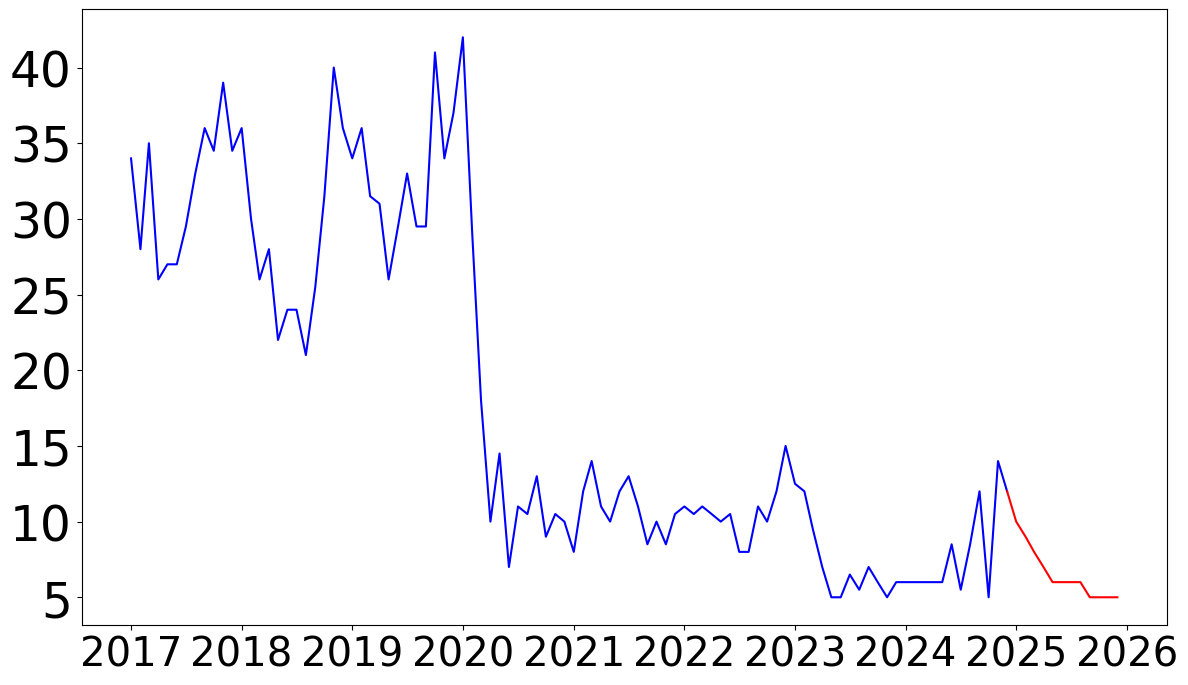

In [10]:
# Prediksi 12 bulan ke depan menggunakan sliding window
def predict_future(model, last_input, months=12):
    future_predictions = []
    current_input = last_input.copy()

    for _ in range(months):
        prediction = model.predict(current_input.reshape((1, timestep, 1)))
        future_predictions.append(prediction[0, 0])
        
        # Geser input window dengan menambahkan prediksi terbaru
        current_input = np.roll(current_input, -1)
        current_input[-1] = prediction[0, 0]

    return np.array(future_predictions).reshape(-1, 1)

# Gunakan data terakhir sebagai input awal
last_input = X_scaled[-timestep:]
future_preds_scaled = predict_future(model_cnn_gru, last_input, months=12)

# Cek nilai sebelum inverse transform
print("Prediksi dalam skala normalisasi:")
print(future_preds_scaled)

# Konversi kembali ke skala asli
future_preds = scaler.inverse_transform(future_preds_scaled)

# Konversi kembali ke skala asli dan ubah ke bilangan bulat
future_preds = scaler.inverse_transform(future_preds_scaled).astype(int)

# Cek nilai setelah inverse transform
print("Prediksi dalam skala asli:")
print(future_preds)

# Buat label bulan untuk prediksi
future_dates = pd.date_range(start=buku_500_copy['Bulan'].values[-1], periods=12, freq='M')

# Simpan hasil prediksi dalam DataFrame untuk analisis lebih lanjut
predictions_df = pd.DataFrame({'Bulan': future_dates, 'Prediksi': future_preds.flatten()})
print("Hasil prediksi dalam DataFrame:")
print(predictions_df)

# Gabungkan data aktual dan prediksi
combined_dates = np.concatenate([buku_500_copy['Bulan'].values, future_dates])
combined_values = np.concatenate([buku_500_copy['Jumlah_buku_dipinjam'].values, future_preds.flatten()])

# Visualisasi hasil prediksi dengan satu garis tetapi warna berbeda
plt.figure(figsize=(14, 8))

# Plot data aktual dengan warna biru
plt.plot(combined_dates[:len(buku_500_copy)], combined_values[:len(buku_500_copy)], color='blue', label='Actual Data')

# Plot data prediksi dengan warna merah (melanjutkan garis sebelumnya)
plt.plot(combined_dates[len(buku_500_copy)-1:], combined_values[len(buku_500_copy)-1:], color='red', label='CNN-GRU Forecast')
plt.xticks(fontsize=29)
plt.yticks(fontsize=35)
plt.show()